### kNN and k-d trees


given a dataset with n points in R^d, we want to find the k nearest neighbours (kNN) for each of many 
query points. 

we will play with a data structure called k-d trees (k-dimensional trees) and try to answer some questions:

* are k-d trees really faster than a brute-force approach (see below)?

we will also discuss:
* important: how does the speed depend on the dimensino?
* why do you think the dimension plays a role?


### Main task:
**determine the largets dimension for which k-d trees are still worth using**

> k-d trees are worth using if using them is faster than using the brute force method.


In [2]:
import numpy as np
from sklearn.neighbors import KDTree
import matplotlib.pyplot as plt

### Brute force approach

the following two functinos use a brute force method by calcualting the Euclidean distance between each element.

In [3]:
def closest_indices(X, q, k):
    '''
    Returns the indices of the k closest elements in X
    (by Euclidean distance) to the query vector v.

    Args:
    X: a 2D np.array of shape (n,d)
    v: an np.array of shape (d)
    k: int value for number of indices to return

    Returns:
    An np.array of k indices
    '''
    # can we be smarter here?
    return np.linalg.norm(X - q, axis=1).argsort()[:k]

# similar to the function above but for multiple query points, Q
def closest_indices_many(X, Q, k):
    '''
    Runs closest_indices for each query q in Q.
    Q is an np.array of query vectors.

    Returns:
    A 2-dimensional np.array containing k indices for each query
    '''
    return np.array([closest_indices(X, q, k) for q in Q])

In [4]:
X = np.array([[-1.0], [2.5], [3.0]])
Q = [[1.1], [2.2], [10], [0.5]]
inds = closest_indices_many(X, Q, 2)
print("indices:", inds)

indices: [[1 2]
 [1 2]
 [2 1]
 [0 1]]


In [8]:
print("data:", X[inds]) #

data: [[[ 2.5]
  [ 3. ]]

 [[ 2.5]
  [ 3. ]]

 [[ 3. ]
  [ 2.5]]

 [[-1. ]
  [ 2.5]]]


In [18]:
from keras.datasets import mnist # dataset of handwritten digits (0-9)

(x_train,_), (x_test,_) = mnist.load_data()

# notebook ignores labels _. so we only keep the images

In [19]:
x_train.shape

(60000, 28, 28)

In [20]:
x_test.shape

(10000, 28, 28)

In [10]:
x_test[0].shape

(28, 28)

In [13]:
query_vector = x_test[0].reshape(28*28)

In [26]:
query_vector.shape 
# nearest neighbor code expects vectors, not image
# so reshpae to 784-d vector (very high dimensional)
# 784-d vector is flat vector

(784,)

In [23]:
nbr_inds = closest_indices(query_vector, x_train.reshape(-1, 28*28), 10)


# -1 means: numpy figure out this dimension automatically
# since x_train originally (60000, 28, 28), reshaping becomes: (60000, 784)
# k = 10, 10 nearest neighbors

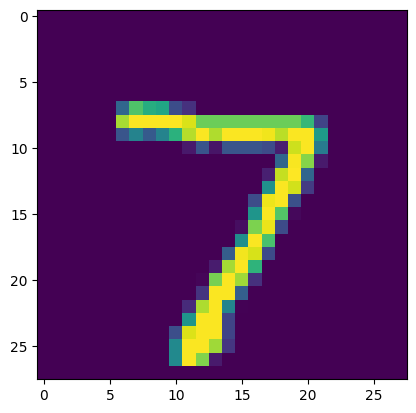

In [27]:
plt.imshow(query_vector.reshape(28,28))
# reshape to image to 2d

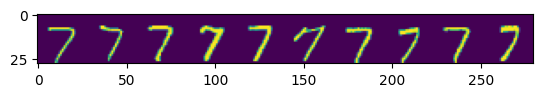

In [ ]:
plt.imshow(np.concatenate(x_train[nbr_inds], axis=1))

#this is showing 10 nearest digits

### We flatten the image to do math, and we reshape it back to display it


an MNIST digit is a 28 x 28 grid of pixels
so python stores it like tihs: shape = (28,28)
so visually it is a 2D picture


but math algorithms don't understand images.
algorithms like k-nearest neighbors only understand vectors of numbers


converting image -> vector (we flatten it)
* (28,28) -> (784,)

rehspae back again to see the digit 
* (784, ) -> (28,28)
